# Extending CRISP: Bond-Angle Distribution (Si–O–Si)

This tutorial shows how to implement a custom analysis (Si–O–Si bond-angle distribution) without modifying CRISP core code.

Bond-Angle Distribution (BAD) Analysis for Si–O–Si Triplets

This tutorial demonstrates how to extend CRISP with a new analysis method by:
1. Reusing CRISP utilities (atomic_indices, interatomic_distances, subsampling)
2. Following established coding patterns from existing analyses
3. Generating standardized outputs (CSV, TXT statistics, HTML plots)

The analysis computes Si–O–Si bond angles over a trajectory to characterise 
the local geometric structure of zeolite frameworks.



Bond-Angle Distribution Analysis
Tutorial: Extending CRISP with Custom Analysis

Loading atomic indices...
  Si atoms: 36
  O atoms: 144
Cutoff file not found, using default: 2.2 Å

Identifying Si–O–Si triplets...
Found 46 Si–O–Si triplets

Analyzing bond angles over trajectory...
Analyzing 2100 frames (skip=10)...
Computed 96600 angle measurements

Computing histogram and statistics...

Saving outputs...
Saved angle data: ./BAD_data/SiO_Si_angles.csv
Saved histogram: ./BAD_data/SiO_Si_histogram.csv
Saved statistics: ./BAD_data/SiO_Si_statistics.txt
Saved matplotlib plot: ./BAD_data/SiO_Si_distribution.png


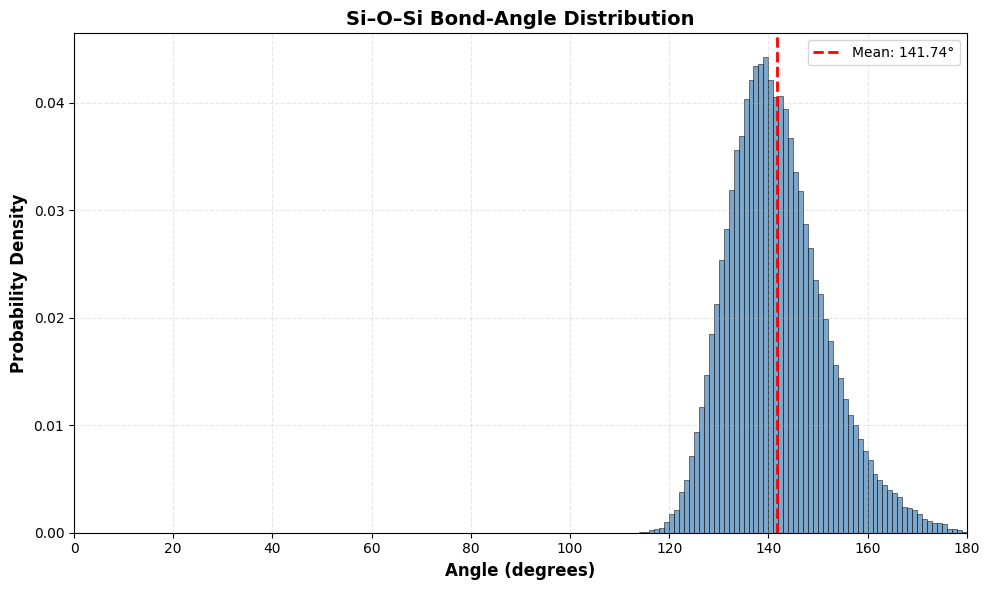

Saved interactive plot: ./BAD_data/SiO_Si_distribution.html

ANALYSIS COMPLETE
Triplets analyzed:    46
Total measurements:   96600
Mean angle:           141.74°
Std deviation:        9.75°



In [4]:
import os
import csv
import numpy as np
from ase.io import read, Trajectory
import matplotlib.pyplot as plt

# ============================================================================
# Inputs and Path
# ============================================================================
file_path = "./al_12_48h2o/nvt_eq.traj"
indices_dir = "./Simulation_Utility/indices_new/"
cutoff_default = 2.2  # Å
out_dir = "./BAD_data"
skip_frames = 10  
show_plots = True  


def load_atomic_indices_from_file(indices_dir, element_symbol):
    """
    Load atomic indices for a given element.
    Pattern from: simulation_utility/atomic_indices.py
    """
    indices_file = os.path.join(indices_dir, f"{element_symbol}_indices.npy")
    if not os.path.exists(indices_file):
        raise FileNotFoundError(f"Indices file not found: {indices_file}")
    indices = np.load(indices_file).flatten()
    return indices.astype(int)


def load_cutoff_from_file(indices_dir, pair_label, default=2.2):
    """
    Load cutoff distance from CSV file.
    Pattern from: simulation_utility/interatomic_distances.py
    """
    cutoff_file = os.path.join(indices_dir, "cutoff", f"{pair_label}_cutoff.csv")
    if not os.path.exists(cutoff_file):
        print(f"Cutoff file not found, using default: {default} Å")
        return float(default)
    
    try:
        with open(cutoff_file, 'r') as f:
            reader = csv.reader(f)
            for row in reader:
                for val in row:
                    try:
                        cutoff_value = float(val)
                        print(f"Loaded {pair_label} cutoff: {cutoff_value:.3f} Å")
                        return cutoff_value
                    except ValueError:
                        continue
    except Exception as e:
        print(f"Error reading cutoff: {e}")
    
    print(f"Using default cutoff: {default} Å")
    return float(default)


def calculate_angle(vec1, vec2):
    """
    Calculate angle between two vectors in degrees.
    Standard geometric utility following CRISP conventions.
    """
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 < 1e-10 or norm2 < 1e-10:
        return 0.0
    cos_angle = np.dot(vec1, vec2) / (norm1 * norm2)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    angle_rad = np.arccos(cos_angle)
    return np.degrees(angle_rad)


# ============================================================================
# Core Analysis Functions
# ============================================================================

def find_bridging_oxygen_triplets(positions, si_indices, o_indices, cutoff):
    """
    Identify Si–O–Si triplets where oxygen bridges two silicon atoms.
    
    Similar pattern to: data_analysis/contact_coordination.py
    Uses geometric distance criteria to identify structural motifs.
    
    Args:
        positions: Atomic positions array (N, 3)
        si_indices: Silicon atom indices
        o_indices: Oxygen atom indices
        cutoff: Si-O distance cutoff in Angstroms
        
    Returns:
        List of triplets: [(si1, o, si2), ...]
    """
    triplet_set = set()
    si_positions = positions[si_indices]
    
    for o_idx in o_indices:
        o_pos = positions[o_idx]
        # Calculate distances to all Si atoms
        distances = np.linalg.norm(si_positions - o_pos, axis=1)
        
        # Find Si neighbors within cutoff
        neighbor_mask = distances <= cutoff
        neighbor_indices = np.where(neighbor_mask)[0]
        
        if len(neighbor_indices) >= 2:
            # Select two closest Si atoms
            sorted_idx = np.argsort(distances[neighbor_indices])
            closest_two = neighbor_indices[sorted_idx[:2]]
            
            si1 = int(si_indices[closest_two[0]])
            si2 = int(si_indices[closest_two[1]])
            
            # Ensure consistent ordering to avoid duplicates
            if si1 > si2:
                si1, si2 = si2, si1
            
            triplet_set.add((si1, int(o_idx), si2))
    
    triplet_list = sorted(list(triplet_set))
    print(f"Found {len(triplet_list)} Si–O–Si triplets")
    return triplet_list


def analyze_bond_angles(traj_file, triplets, skip=1):
    """
    Compute bond angles over trajectory frames.
    
    Pattern from: data_analysis/h_bond.py, data_analysis/msd.py
    Frame-by-frame analysis with optional subsampling.
    
    Args:
        traj_file: Path to trajectory file
        triplets: List of (si1, o, si2) triplets
        skip: Frame skip interval for subsampling
        
    Returns:
        List of tuples: (frame, si1, o, si2, angle)
    """
    traj = read(traj_file, index=f'::{skip}')
    if not isinstance(traj, list):
        traj = [traj]
    
    n_frames = len(traj)
    print(f"Analyzing {n_frames} frames (skip={skip})...")
    
    angle_data = []
    for frame_idx, atoms in enumerate(traj):
        positions = atoms.get_positions()
        
        for (si1_idx, o_idx, si2_idx) in triplets:
            # Vectors from oxygen to each silicon
            vec_o_si1 = positions[si1_idx] - positions[o_idx]
            vec_o_si2 = positions[si2_idx] - positions[o_idx]
            
            # Calculate angle
            angle = calculate_angle(vec_o_si1, vec_o_si2)
            angle_data.append((frame_idx * skip, si1_idx, o_idx, si2_idx, angle))
    
    print(f"Computed {len(angle_data)} angle measurements")
    return angle_data


def compute_histogram_statistics(angles, bins=180):
    """
    Calculate histogram and statistics for angle distribution.
    Pattern from: data_analysis/contact_coordination.py
    """
    angles_array = np.array(angles)
    
    # Histogram
    counts, bin_edges = np.histogram(angles_array, bins=bins, range=(0, 180))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Normalized density
    total_counts = np.sum(counts)
    normalized_density = counts / total_counts if total_counts > 0 else counts
    
    # Statistics
    stats = {
        'mean': float(np.mean(angles_array)),
        'median': float(np.median(angles_array)),
        'std': float(np.std(angles_array)),
        'min': float(np.min(angles_array)),
        'max': float(np.max(angles_array)),
        'count': len(angles_array)
    }
    
    return bin_centers, counts, normalized_density, stats

def write_angles_to_csv(output_file, angle_data):
    """
    Save raw angle data to CSV.
    Pattern from: data_analysis/h_bond.py (hydrogen_bonds.csv output)
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['frame', 'Si1_idx', 'O_idx', 'Si2_idx', 'angle_deg'])
        writer.writerows(angle_data)
    print(f"Saved angle data: {output_file}")


def write_histogram_to_csv(output_file, bin_centers, counts, density):
    """
    Save histogram data to CSV.
    Pattern from: data_analysis/contact_coordination.py
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['angle_deg', 'count', 'normalized_density'])
        for center, count, dens in zip(bin_centers, counts, density):
            writer.writerow([f'{center:.3f}', int(count), f'{dens:.6f}'])
    print(f"Saved histogram: {output_file}")


def write_statistics_to_txt(output_file, stats):
    """
    Save summary statistics to text file.
    Pattern from: data_analysis/contact_coordination.py (_statistics.txt)
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, 'w') as f:
        f.write("Si–O–Si Bond-Angle Distribution Analysis\n")
        f.write("=" * 50 + "\n\n")
        f.write(f"Total measurements: {stats['count']}\n")
        f.write(f"Mean angle: {stats['mean']:.4f}°\n")
        f.write(f"Median angle: {stats['median']:.4f}°\n")
        f.write(f"Standard deviation: {stats['std']:.4f}°\n")
        f.write(f"Min angle: {stats['min']:.4f}°\n")
        f.write(f"Max angle: {stats['max']:.4f}°\n")
    print(f"Saved statistics: {output_file}")


def create_distribution_plot_matplotlib(output_file, angles, stats, show=False):
    """
    Generate static distribution plot.
    Pattern from: data_analysis/prdf.py (matplotlib output)
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogram
    ax.hist(angles, bins=180, range=(0, 180), density=True,
            alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Mean line
    ax.axvline(stats['mean'], color='red', linestyle='--', linewidth=2,
               label=f"Mean: {stats['mean']:.2f}°")
    
    # Labels and formatting
    ax.set_xlabel('Angle (degrees)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
    ax.set_title('Si–O–Si Bond-Angle Distribution', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, 180)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved matplotlib plot: {output_file}")
    
    if show:
        plt.show()
    else:
        plt.close()


def create_distribution_plot_plotly(output_file, angles, stats):
    """
    Generate interactive HTML plot.
    Pattern from: data_analysis/h_bond.py, data_analysis/volumetric_atomic_density.py
    """
    if not PLOTLY_AVAILABLE:
        print("Plotly not available, skipping HTML plot")
        return
    
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    # Create figure
    fig = go.Figure()
    
    # Add histogram
    fig.add_trace(go.Histogram(
        x=angles,
        nbinsx=180,
        name='Angle Distribution',
        marker_color='steelblue',
        opacity=0.75,
        xbins=dict(start=0, end=180, size=1)
    ))
    
    # Add mean line
    fig.add_vline(
        x=stats['mean'],
        line_dash="dash",
        line_color="red",
        line_width=2,
        annotation_text=f"Mean: {stats['mean']:.2f}°",
        annotation_position="top right"
    )
    
    # Layout
    fig.update_layout(
        title="Si–O–Si Bond-Angle Distribution",
        xaxis_title="Angle (degrees)",
        yaxis_title="Count",
        font=dict(size=12),
        showlegend=True,
        hovermode='x unified',
        template='plotly_white',
        bargap=0.05
    )
    
    fig.write_html(output_file, include_plotlyjs='cdn')
    print(f"Saved interactive plot: {output_file}")


# ============================================================================
# Main Analysis Workflow
# ============================================================================

def main():
    """
    Main workflow demonstrating CRISP extensibility:
    1. Load atomic indices and cutoffs
    2. Identify geometric features (Si-O-Si triplets)
    3. Analyze trajectory
    4. Generate outputs in multiple formats
    """
    print("\n" + "=" * 70)
    print("Bond-Angle Distribution Analysis")
    print("Tutorial: Extending CRISP with Custom Analysis")
    print("=" * 70 + "\n")
    
    # Load atomic indices
    print("Loading atomic indices...")
    si_indices = load_atomic_indices_from_file(indices_dir, "Si")
    o_indices = load_atomic_indices_from_file(indices_dir, "O")
    print(f"  Si atoms: {len(si_indices)}")
    print(f"  O atoms: {len(o_indices)}")
    
    # Load cutoff
    cutoff = load_cutoff_from_file(indices_dir, "Si-O", cutoff_default)
    
    # Load first frame and identify triplets
    print("\nIdentifying Si–O–Si triplets...")
    first_frame = read(file_path, index=0)
    positions = first_frame.get_positions()
    triplets = find_bridging_oxygen_triplets(positions, si_indices, o_indices, cutoff)
    
    if len(triplets) == 0:
        raise ValueError("No Si–O–Si triplets found. Check cutoff value.")
    
    # Analyze trajectory
    print("\nAnalyzing bond angles over trajectory...")
    angle_data = analyze_bond_angles(file_path, triplets, skip=skip_frames)
    angles = [row[4] for row in angle_data]
    
    # Compute statistics
    print("\nComputing histogram and statistics...")
    bin_centers, counts, density, stats = compute_histogram_statistics(angles)
    
    # Save outputs
    print("\nSaving outputs...")
    write_angles_to_csv(
        os.path.join(out_dir, "SiO_Si_angles.csv"),
        angle_data
    )
    write_histogram_to_csv(
        os.path.join(out_dir, "SiO_Si_histogram.csv"),
        bin_centers, counts, density
    )
    write_statistics_to_txt(
        os.path.join(out_dir, "SiO_Si_statistics.txt"),
        stats
    )
    create_distribution_plot_matplotlib(
        os.path.join(out_dir, "SiO_Si_distribution.png"),
        angles, stats, show=show_plots
    )
    create_distribution_plot_plotly(
        os.path.join(out_dir, "SiO_Si_distribution.html"),
        angles, stats
    )
    
    # Summary
    print("\n" + "=" * 70)
    print("ANALYSIS COMPLETE")
    print("=" * 70)
    print(f"Triplets analyzed:    {len(triplets)}")
    print(f"Total measurements:   {stats['count']}")
    print(f"Mean angle:           {stats['mean']:.2f}°")
    print(f"Std deviation:        {stats['std']:.2f}°")
    print("=" * 70 + "\n")


if __name__ == "__main__":
    main()